Número de delanteros puros: (369, 36)


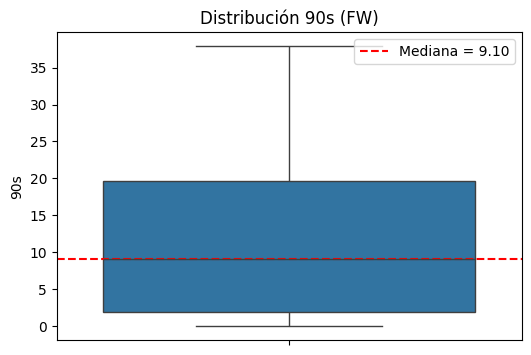

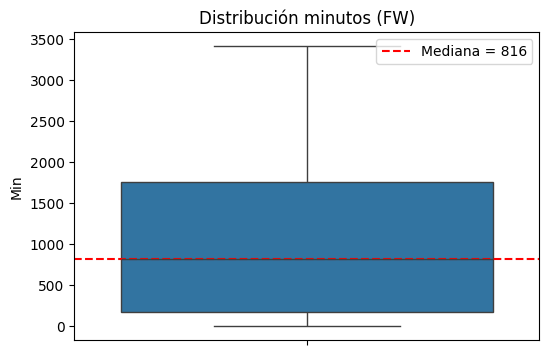

Mediana 90s: 9.10
Mediana Min: 816

Tras filtro de experiencia: (1517, 36)


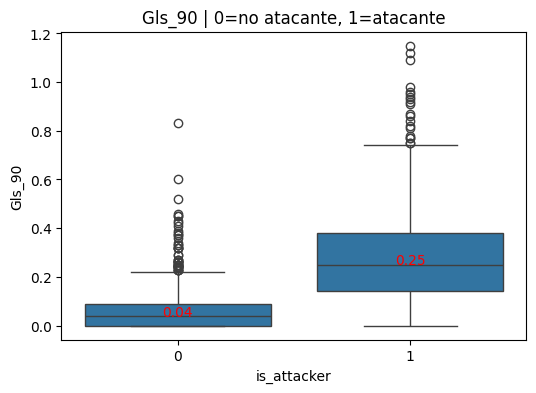

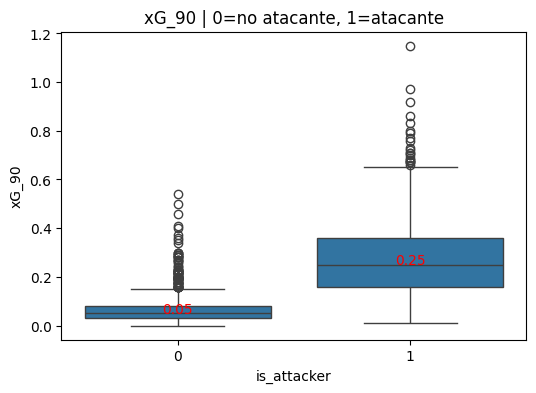

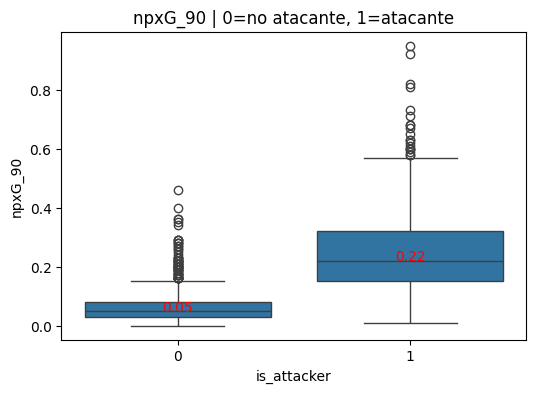

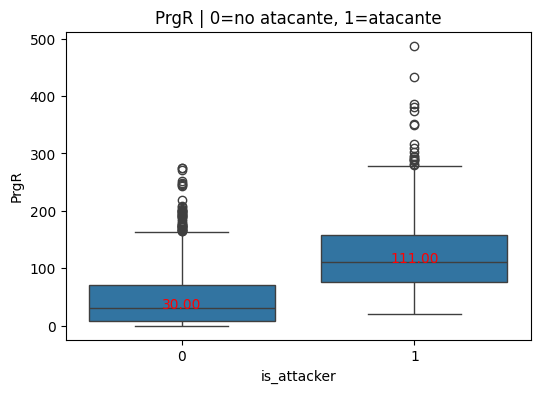


=== LOGÍSTICA ===
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       251
           1       0.78      0.87      0.82       129

    accuracy                           0.87       380
   macro avg       0.86      0.87      0.86       380
weighted avg       0.88      0.87      0.88       380

ROC AUC: 0.9526236140708484

Top variables:
   variable  importance
9      PrgP    1.464500
16  npxG_90    1.173138
15   xAG_90    0.939966
10     PrgR    0.901618
8      PrgC    0.848093
14    xG_90    0.720624
1       Ast    0.533354
2       G+A    0.475918
4        xG    0.399869
11   Gls_90    0.338999
0       Gls    0.338834
13   G+A_90    0.205039
5      npxG    0.163965
6       xAG    0.126189
12   Ast_90    0.100442

Variables usadas en correlación:
['is_attacker', 'Gls', 'Ast', 'G+A', 'G-PK', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'Gls_90', 'Ast_90', 'G+A_90', 'xG_90', 'xAG_90', 'npxG_90']


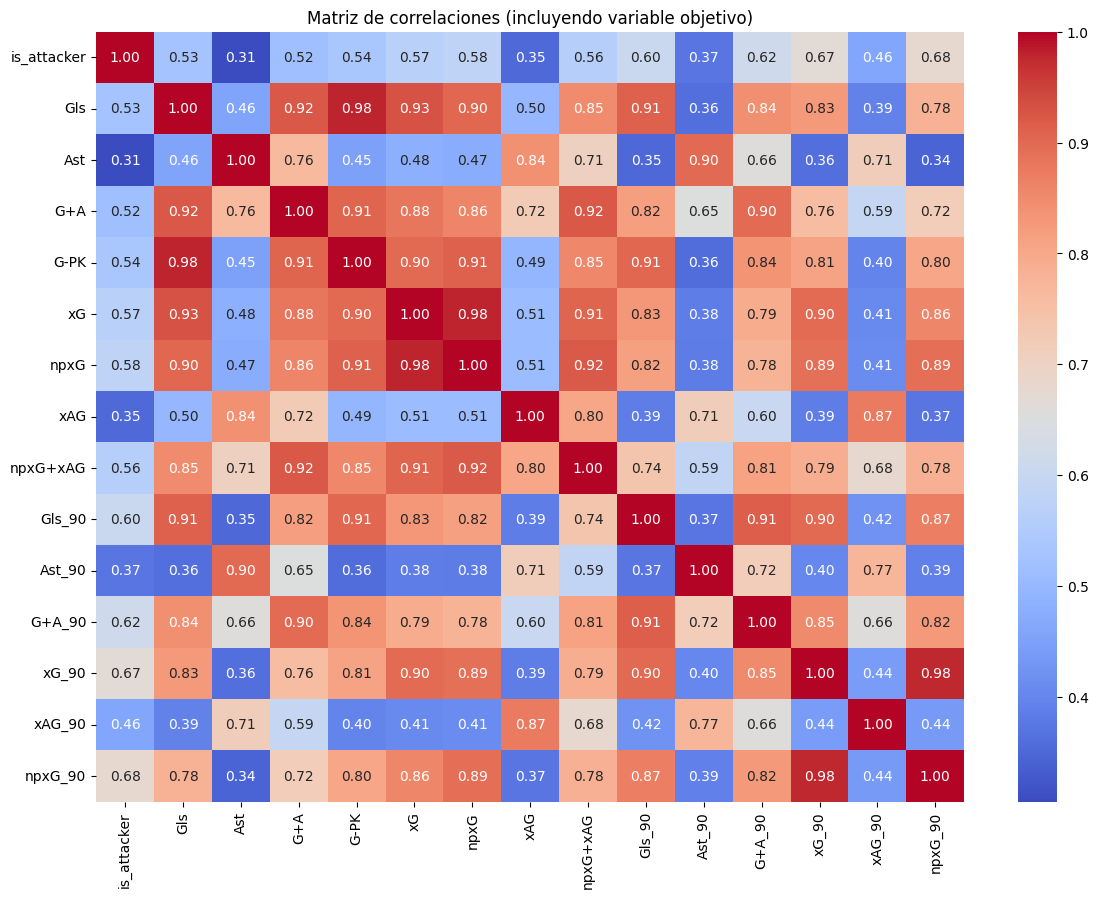


Variables finales:
['Gls', 'Ast', 'xAG', 'PrgC', 'PrgP', 'PrgR']

FW candidatos: (145, 37)

Silhouette:
   k  silhouette
0  2    0.464645
1  3    0.362381
2  4    0.372116
3  5    0.332811
4  6    0.324557

Cluster TOP: 1

=== TOP DELANTEROS ===
                 Player           Squad   Age  top_score  Gls_90  xG_90  \
34      Ousmane Dembélé       Paris S-G  27.0   2.841277    1.09   0.86   
113       Mateo Retegui        Atalanta  25.0   1.936857    0.94   0.71   
10      Bradley Barcola       Paris S-G  21.0   1.686417    0.58   0.55   
77        Omar Marmoush  Eint Frankfurt  25.0   1.585006    0.93   0.55   
59       Alexander Isak   Newcastle Utd  24.0   1.522241    0.75   0.66   
51      Serhou Guirassy        Dortmund  28.0   1.500442    0.73   0.79   
44         Hugo Ekitike  Eint Frankfurt  22.0   1.472220    0.53   0.76   
123          Leroy Sané   Bayern Munich  28.0   1.349021    0.60   0.56   
89   Georges Mikautadze            Lyon  23.0   1.153465    0.68   0.64   
105

In [11]:
# =========================================================
# SCOUTING DELANTEROS | TOP 5 LIGAS EUROPEAS | TEMPORADA 24-25
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

# =========================================================
# CARGA
# =========================================================

file_path = "top5-players24-25.csv"
df = pd.read_csv(file_path, sep=";", encoding="utf-8-sig")

# =========================================================
# LIMPIEZA INICIAL
# =========================================================

df = df.dropna(subset=["Pos", "Age"]).copy()
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# eliminar porteros
df = df[~df["Pos"].str.contains("GK", na=False)].copy()

# asegurar numéricas
df["90s"] = pd.to_numeric(df["90s"], errors="coerce")
df["Min"] = pd.to_numeric(df["Min"], errors="coerce")

# =========================================================
# EDA EXPERIENCIA (SOLO DELANTEROS PUROS FW)
# =========================================================

def is_pure_fw(pos):
    if pd.isna(pos):
        return False
    positions = [p.strip() for p in str(pos).split(",")]
    return positions == ["FW"]

fw_temp = df[df["Pos"].apply(is_pure_fw)].copy()

print("Número de delanteros puros:", fw_temp.shape)

# -------- BOXPLOT 90s --------
plt.figure(figsize=(6,4))
sns.boxplot(y=fw_temp["90s"])

median_90s = fw_temp["90s"].median()
plt.axhline(median_90s, color='red', linestyle='--', label=f"Mediana = {median_90s:.2f}")
plt.title("Distribución 90s (FW)")
plt.legend()
plt.show()

# -------- BOXPLOT Min --------
plt.figure(figsize=(6,4))
sns.boxplot(y=fw_temp["Min"])

median_min = fw_temp["Min"].median()
plt.axhline(median_min, color='red', linestyle='--', label=f"Mediana = {median_min:.0f}")
plt.title("Distribución minutos (FW)")
plt.legend()
plt.show()

print(f"Mediana 90s: {median_90s:.2f}")
print(f"Mediana Min: {median_min:.0f}")

# =========================================================
# FILTRO DE EXPERIENCIA
# =========================================================

df = df[(df["90s"] > 9) & (df["Min"] > 816)].copy()

print("\nTras filtro de experiencia:", df.shape)

# =========================================================
# DEFINIR ATACANTES (FW + LW + RW)
# =========================================================

def is_attacker(pos):
    pos = str(pos)
    return int(("FW" in pos) or ("LW" in pos) or ("RW" in pos))

df["is_attacker"] = df["Pos"].apply(is_attacker)

# =========================================================
# VARIABLES CANDIDATAS
# =========================================================

candidate_features = [
    "Gls", "Ast", "G+A", "G-PK",
    "xG", "npxG", "xAG", "npxG+xAG",
    "PrgC", "PrgP", "PrgR",
    "Gls_90", "Ast_90", "G+A_90",
    "xG_90", "xAG_90", "npxG_90"
]

candidate_features = [c for c in candidate_features if c in df.columns]

model_df = df[["Player", "Pos", "Age", "is_attacker"] + candidate_features].dropna()

# =========================================================
# EDA OFENSIVO (BOXPLOTS)
# =========================================================

eda_vars = ["Gls_90", "xG_90", "npxG_90", "PrgR"]
eda_vars = [c for c in eda_vars if c in model_df.columns]

for col in eda_vars:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=model_df, x="is_attacker", y=col)

    medians = model_df.groupby("is_attacker")[col].median()

    for i, val in enumerate(medians):
        plt.text(i, val, f"{val:.2f}", ha='center', color='red')

    plt.title(f"{col} | 0=no atacante, 1=atacante")
    plt.show()

# =========================================================
# REGRESIÓN LOGÍSTICA (IMPORTANCIA VARIABLES)
# =========================================================

X = model_df[candidate_features]
y = model_df["is_attacker"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

logit = LogisticRegression(max_iter=5000, class_weight="balanced")
logit.fit(X_train, y_train)

print("\n=== LOGÍSTICA ===")
print(classification_report(y_test, logit.predict(X_test)))
print("ROC AUC:", roc_auc_score(y_test, logit.predict_proba(X_test)[:,1]))

coef_df = pd.DataFrame({
    "variable": candidate_features,
    "importance": np.abs(logit.coef_[0])
}).sort_values("importance", ascending=False)

print("\nTop variables:")
print(coef_df.head(15))

# =========================================================
# MATRIZ DE CORRELACIONES CON VARIABLE OBJETIVO
# =========================================================

# usamos el dataframe del modelo (ya limpio)
target_var = "is_attacker"

# lista amplia de variables ofensivas
corr_candidates = [
    target_var,
    'Gls', 'Ast', 'G+A', 'G-PK',
    'xG', 'npxG', 'xAG', 'npxG+xAG',
    'Gls_90', 'Ast_90', 'G+A_90',
    'G-PK_90', 'G+A-PK_90',
    'xG_90', 'xAG_90', 'xG+xAG_90',
    'npxG_90', 'npxG+xAG_90'
]

# nos quedamos solo con las columnas que existen
corr_vars = [c for c in corr_candidates if c in model_df.columns]

# subset limpio
df_corr = model_df[corr_vars].dropna()

print("\nVariables usadas en correlación:")
print(corr_vars)

# cálculo correlación
corr_matrix = df_corr.corr()

# visualización
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Matriz de correlaciones (incluyendo variable objetivo)")
plt.show()

# =========================================================
# ELIMINAR CORRELACIÓN
# =========================================================

corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

X_reduced = X.drop(columns=to_drop)
selected_features = X_reduced.columns.tolist()

print("\nVariables finales:")
print(selected_features)

# =========================================================
# FILTRAR FW PUROS (CLUSTERING)
# =========================================================

fw_df = df[df["Pos"].apply(is_pure_fw)].copy()
fw_df = fw_df[fw_df["Age"] < 29]

# excluir Real Madrid
fw_df = fw_df[~fw_df["Squad"].str.lower().str.contains("madrid", na=False)]

fw_df = fw_df.dropna(subset=selected_features).reset_index(drop=True)

print("\nFW candidatos:", fw_df.shape)

# =========================================================
# KMEANS
# =========================================================

X_cluster = fw_df[selected_features]

scaler_cluster = StandardScaler()
X_scaled_cluster = scaler_cluster.fit_transform(X_cluster)

results = []
for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled_cluster)
    results.append((k, silhouette_score(X_scaled_cluster, labels)))

sil_df = pd.DataFrame(results, columns=["k", "silhouette"])
print("\nSilhouette:")
print(sil_df)

best_k = int(sil_df.sort_values("silhouette", ascending=False).iloc[0]["k"])

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
fw_df["cluster"] = kmeans.fit_predict(X_scaled_cluster)

# =========================================================
# SCORE OFENSIVO
# =========================================================

score_vars = [c for c in ["Gls_90", "xG_90", "npxG_90", "G+A_90", "PrgR"] if c in fw_df.columns]

score_scaled = pd.DataFrame(
    StandardScaler().fit_transform(fw_df[score_vars]),
    columns=score_vars
)

fw_df["top_score"] = score_scaled.mean(axis=1)

cluster_score = fw_df.groupby("cluster")["top_score"].mean().sort_values(ascending=False)
top_cluster = cluster_score.index[0]

print("\nCluster TOP:", top_cluster)

# =========================================================
# RESULTADO FINAL
# =========================================================

final_df = fw_df[fw_df["cluster"] == top_cluster].copy()
final_df = final_df.sort_values("top_score", ascending=False)

cols = ["Player", "Squad", "Age", "top_score"] + score_vars
cols = [c for c in cols if c in final_df.columns]

print("\n=== TOP DELANTEROS ===")
print(final_df[cols].head(20))

# =========================================================
# EXPORTAR
# =========================================================

final_df.to_csv("ranking_delanteros_final.csv", sep=";", index=False)

print("\nArchivo exportado correctamente.")


Variables usadas en correlación:
['is_attacker', 'Gls', 'Ast', 'G+A', 'G-PK', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'Gls_90', 'Ast_90', 'G+A_90', 'xG_90', 'xAG_90', 'npxG_90']


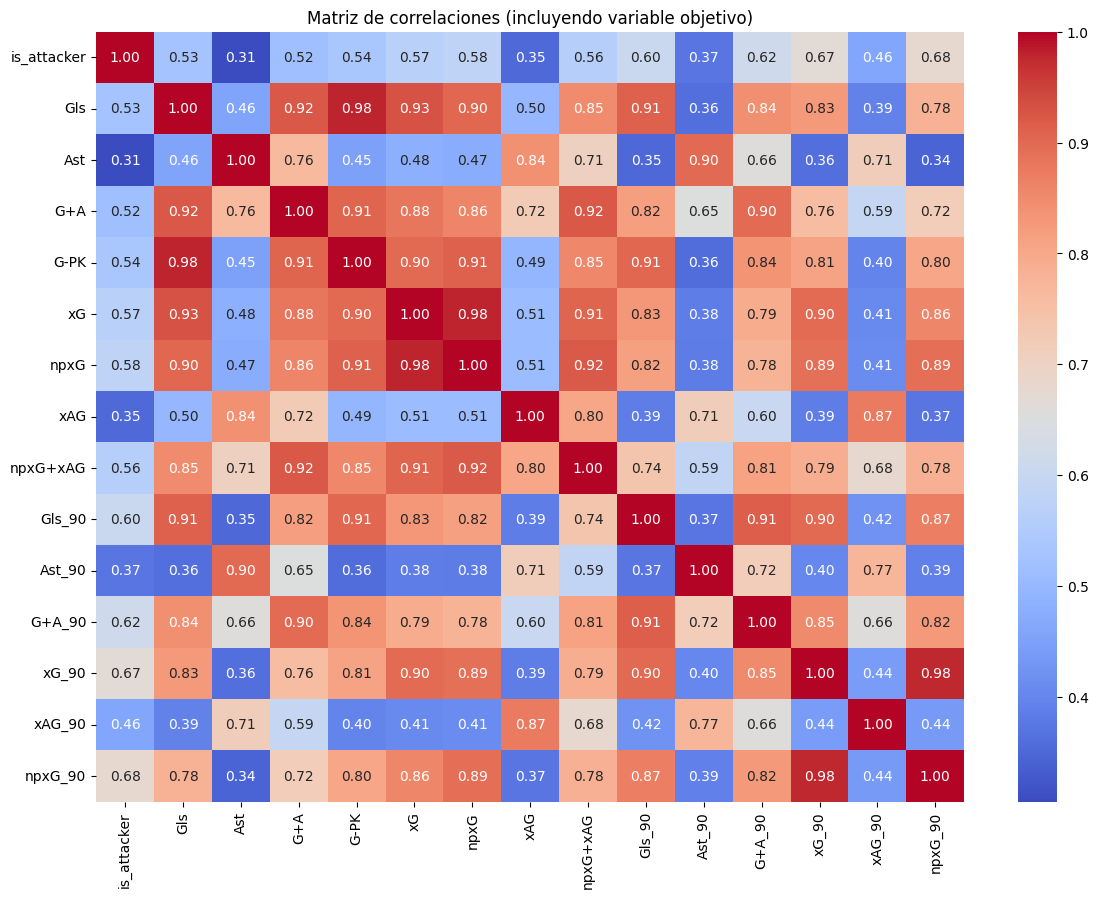

In [12]:
# =========================================================
# MATRIZ DE CORRELACIONES CON VARIABLE OBJETIVO
# =========================================================

# usamos el dataframe del modelo (ya limpio)
target_var = "is_attacker"

# lista amplia de variables ofensivas
corr_candidates = [
    target_var,
    'Gls', 'Ast', 'G+A', 'G-PK',
    'xG', 'npxG', 'xAG', 'npxG+xAG',
    'Gls_90', 'Ast_90', 'G+A_90',
    'G-PK_90', 'G+A-PK_90',
    'xG_90', 'xAG_90', 'xG+xAG_90',
    'npxG_90', 'npxG+xAG_90'
]

# nos quedamos solo con las columnas que existen
corr_vars = [c for c in corr_candidates if c in model_df.columns]

# subset limpio
df_corr = model_df[corr_vars].dropna()

print("\nVariables usadas en correlación:")
print(corr_vars)

# cálculo correlación
corr_matrix = df_corr.corr()

# visualización
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Matriz de correlaciones (incluyendo variable objetivo)")
plt.show()


Varianza explicada por componentes:
[0.73666691 0.13604576]


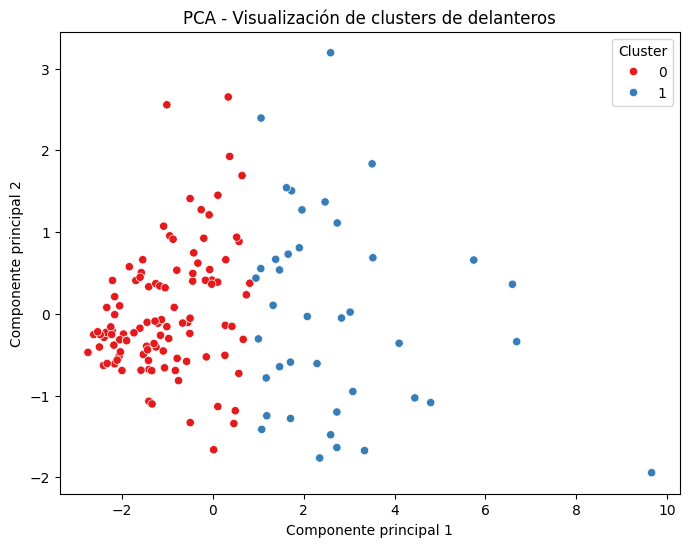

In [13]:
# =========================================================
# PCA (VISUALIZACIÓN DE CLUSTERS)
# =========================================================

from sklearn.decomposition import PCA

# aplicar PCA sobre los datos ya escalados
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_cluster)

# crear dataframe con resultados
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": fw_df["cluster"]
})

# varianza explicada
print("\nVarianza explicada por componentes:")
print(pca.explained_variance_ratio_)

# gráfico
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1"
)

plt.title("PCA - Visualización de clusters de delanteros")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Cluster")
plt.show()

In [14]:
# añadir nombres de jugadores al gráfico
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": fw_df["cluster"].values,
    "Player": fw_df["Player"].values
})

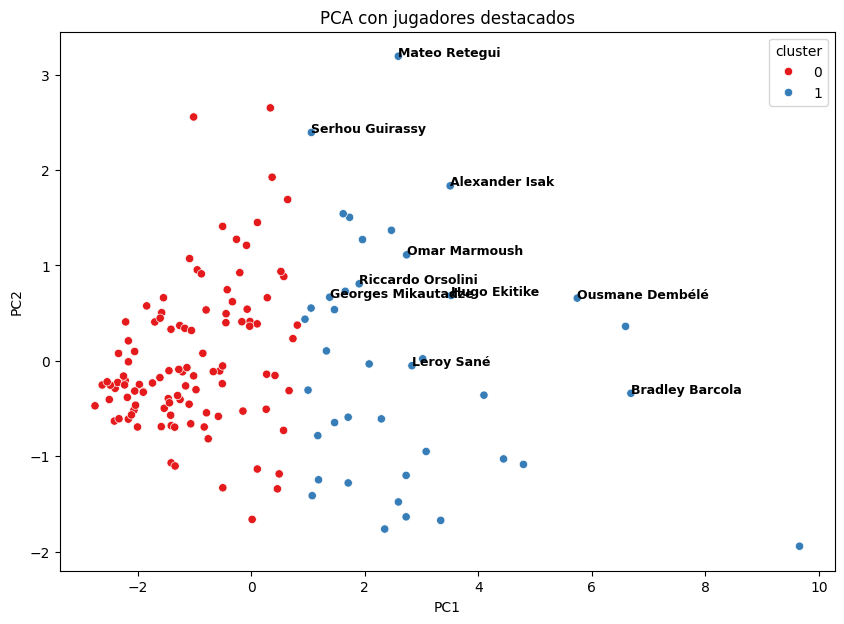

In [15]:
# mostrar nombres de los 10 mejores jugadores del cluster top
top_players = final_df["Player"].head(10).values

plt.figure(figsize=(10,7))

# gráfico de dispersión con nombres
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1"
)

for i in range(len(pca_df)):
    if pca_df["Player"].iloc[i] in top_players:
        plt.text(
            pca_df["PC1"].iloc[i],
            pca_df["PC2"].iloc[i],
            pca_df["Player"].iloc[i],
            fontsize=9,
            fontweight="bold"
        )

plt.title("PCA con jugadores destacados")
plt.show()

In [16]:
# =========================================================
# IMPORTANCIA DE VARIABLES EN PCA
# =========================================================

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=selected_features
)

print("\nCargas de las variables en PCA:")
print(loadings.sort_values("PC1", ascending=False))


Cargas de las variables en PCA:
           PC1       PC2
PrgR  0.449832 -0.099891
xAG   0.446500 -0.032294
PrgP  0.439276 -0.144228
PrgC  0.413115 -0.407006
Ast   0.405336  0.138325
Gls   0.265263  0.885093
